On a un pb de régression

modèles à essayer : régression linéaire, KNN, forets aléatoires, xgboost, réseaux de neuronnes
(notamment des RNN car séries temporelles)

mélangent de modèles ? 


QUESTIONNEMENT : 

- prédire les deux sorties à la fois ou les deux séparément ?
La question se pose surtout
pour les réseaux de neuronnes : des études ont montré que dans certains cas (je me rappelle plus lesquels)
cela améliore la performance car cela oblige le réseau de neuronnes à comprendre dans la profondeur les
données

- Quel retard choisir ?? 
Peut être choisir par validation croisée ? 

- peu de données ... 1000 observations --> attention au surapprentissage 








On importe les modules et packages nécessaires pour le on fonctionnement du code (peut être faire un 
requirements.txt puis pip install -r requirements.txt)

In [9]:
#%pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

chargement des données et première exploration des données

['Utr', 'Ytr', 'Uts1', 'Uts2']
Utr shape: (1000, 2)
Ytr shape: (1000, 2)
Uts shape: (1000, 2)
Uts2 shape: (1000, 2)
       Utr0      Utr1
0  1.225856  0.043213
1 -0.379083 -0.411898
2  0.683140 -0.921644
3  0.374853 -0.572683
4  0.256665 -0.760764
       Ytr0      Ytr1
0  0.000000  0.000000
1  0.042170  0.720120
2 -0.016521 -0.222306
3 -0.235810  0.020866
4 -0.080339 -0.352666


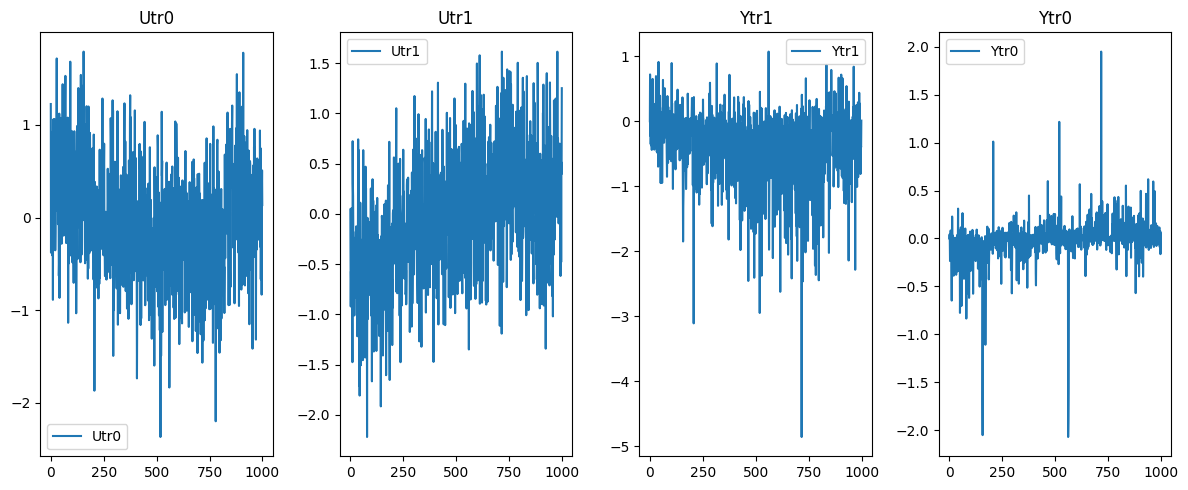

In [10]:
# Charger le fichier
data = np.load('StudentdataNARX.npz')

# Voir la liste des variables
print(data.files)


Utr = data['Utr']
Ytr = data['Ytr']
Uts = data['Uts1']
Uts2 = data['Uts2']

print("Utr shape:", Utr.shape)
print("Ytr shape:", Ytr.shape)
print("Uts shape:", Uts.shape)
print("Uts2 shape:", Uts2.shape)



# transformer les données de train en dataframe pandas
X = pd.DataFrame(Utr, columns=[f'Utr{i}' for i in range(Utr.shape[1])])
Y = pd.DataFrame(Ytr, columns=[f'Ytr{i}' for i in range(Ytr.shape[1])])
print(X.head(5))
print(Y.head(5))



figure, axes = plt.subplots(1, 4, figsize=(12, 5))
axes[0].plot(X['Utr0'], label='Utr0')
axes[0].set_title('Utr0')
axes[0].legend()
axes[1].plot(X['Utr1'], label='Utr1')
axes[1].set_title('Utr1')
axes[1].legend()
axes[2].plot(Y['Ytr1'], label='Ytr1')
axes[2].set_title('Ytr1')
axes[2].legend()
axes[3].plot(Y['Ytr0'], label='Ytr0')
axes[3].set_title('Ytr0')
axes[3].legend()
plt.tight_layout()
plt.show()


On a des données très très bruitées .... Utiliser des pilotes très bruités

In [11]:
# calculer la corrélation entre les différentes variables
df_total = pd.concat([X], axis=1)
correlation_matrix_total = df_total.corr()
print("Correlation matrix:\n", correlation_matrix_total)

Correlation matrix:
          Utr0     Utr1
Utr0  1.00000 -0.16708
Utr1 -0.16708  1.00000


Les coefficients ne sont pas si élevés que ca ... la régression linéaire sur ces variables explicatives semblent compromis

- REGRESSION LINEAIRE 

On va d'abord faire une régression linéaire en utilisant simplement les valeurs de u1 et u2 pour prédire y. On s'attend cependant à des résultats plutôt moyen 

Mean Squared Error: 0.023160909192088595
Coefficients: [-0.02791764  0.05391829]
Intercept: -0.025814008097196896
Mean Prediction MSE: 0.024082345888018608


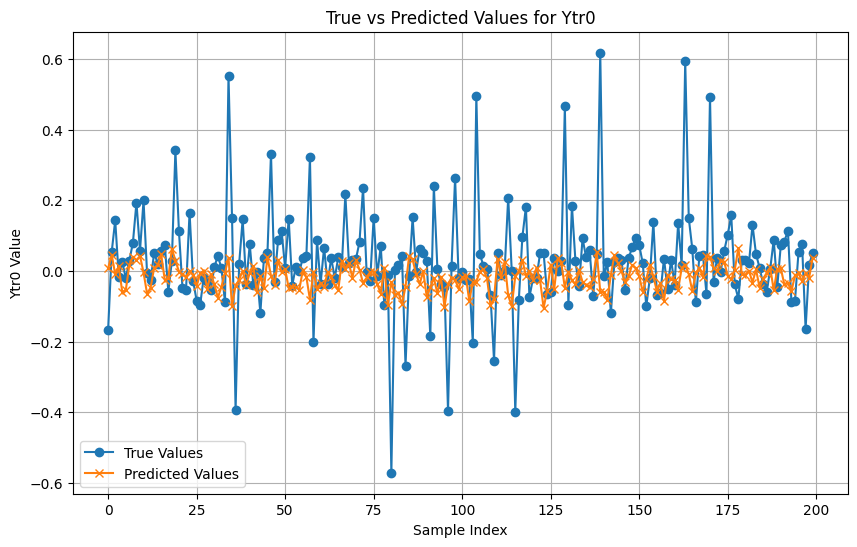

In [12]:
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]

model = LinearRegression()
model.fit(X_train, Y_train["Ytr0"])
Y_pred = model.predict(X_val)
mse = mean_squared_error(Y_val["Ytr0"], Y_pred)
print("Mean Squared Error:", mse)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# erreur si on prédit la valeur moyenne de Ytr0
mean_prediction = np.mean(Y_train["Ytr0"])
mean_mse = mean_squared_error(Y_val["Ytr0"], [mean_prediction] * len(Y_val))
print("Mean Prediction MSE:", mean_mse)


# affichage des résultats
plt.figure(figsize=(10, 6))
plt.plot(Y_val["Ytr0"].values, label='True Values', marker='o')
plt.plot(Y_pred, label='Predicted Values', marker='x')
plt.title('True vs Predicted Values for Ytr0')
plt.xlabel('Sample Index')
plt.ylabel('Ytr0 Value')
plt.legend()
plt.grid()
plt.show()

On voit bien en comparant le mse d'un modèle qui prédit la moyenne de Ytr0 que le modèle 
de régression linéaire uniquement sur l'instant t

In [13]:
X["Utr0_lag1"] = X["Utr0"].shift(1)
X["Utr1_lag1"] = X["Utr1"].shift(1)
X["Ytr0_lag1"] = Y["Ytr0"].shift(1)
X["Ytr1_lag1"] = Y["Ytr1"].shift(1)
X["Utr0_lag2"] = X["Utr0"].shift(2)
X["Utr1_lag2"] = X["Utr1"].shift(2)
X["Ytr0_lag2"] = Y["Ytr0"].shift(2)
X["Ytr1_lag2"] = Y["Ytr1"].shift(2)
X["Utr0_lag3"] = X["Utr0"].shift(3)
X["Utr1_lag3"] = X["Utr1"].shift(3)
X["Ytr0_lag3"] = Y["Ytr0"].shift(3)
X["Ytr1_lag3"] = Y["Ytr1"].shift(3)
X = X.dropna()
Y = Y.loc[X.index] # le dropna a supprimé les 3 premières lignes et n'a pas modifié les index
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]
model = LinearRegression()
model.fit(X_train, Y_train["Ytr0"])
Y_pred = model.predict(X_val)
mse = mean_squared_error(Y_val["Ytr0"], Y_pred)
print("Mean Squared Error with lags:", mse)


Mean Squared Error with lags: 0.01871487703513115


Le problème c'est que là je connais le futur donc j'utilise les données réelles pour yk-1, etc et non les données prédites ... Cela evite l'effet boule de neige mais ce ne sera pas le cas en vrai ...

In [14]:
# utiliser sa propre prédiction comme entrée pour les prédictions futures
Y_pred_future = []
current_input = X_val.iloc[0].copy() # copy pour ne pas modifier X_val
for i in range(len(X_val)):
    pred = model.predict(current_input.values.reshape(1, -1))[0]
    Y_pred_future.append(pred)
    current_input["Ytr0_lag1"] = pred
    current_input["Ytr0_lag2"] = current_input["Ytr0_lag1"]
    current_input["Ytr0_lag3"] = current_input["Ytr0_lag2"]
    current_input["Utr0_lag1"] = current_input["Utr0"]
    current_input["Utr1_lag1"] = current_input["Utr1"]
    current_input["Utr0_lag2"] = current_input["Utr0_lag1"]
    current_input["Utr1_lag2"] = current_input["Utr1_lag1"]
    current_input["Utr0_lag3"] = current_input["Utr0_lag2"]
    current_input["Utr1_lag3"] = current_input["Utr1_lag2"]
mse_future = mean_squared_error(Y_val["Ytr0"], Y_pred_future)
print("Mean Squared Error with future predictions:", mse_future)

Mean Squared Error with future predictions: 0.02080700173974037


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p